# Triple Products

Cycle-test circuits for measuring the real parts of triple products `Re tr(σ_i σ_j σ_k)` for WH orbit states in `cirq_sic`.

In [4]:
from math import comb
import numpy as np
import cirq

from cirq_sic import *

In [4]:
d = 4
phi = load_sic_fiducial(d)
prepare_fiducial = ansatz_circuit(phi)

triples = [(0, 0), (1, 0), (2, 1)]
prepare_states = [
    (lambda qubits, a1=a1, a2=a2: wh_state(qubits, prepare_fiducial, a1, a2))
    for a1, a2 in triples
]

qubits = cirq.LineQubit.range(1 + 3 * int(np.log2(d)))
control_qubit = qubits[0]
n = int(np.log2(d))
register1 = qubits[1 : 1 + n]
register2 = qubits[1 + n : 1 + 2 * n]
register3 = qubits[1 + 2 * n : 1 + 3 * n]

circuit = triple_product_measurement_circuit(
    control_qubit,
    register1,
    register2,
    register3,
    prepare_states[0],
    prepare_states[1],
    prepare_states[2],
)

probabilities = exact_simulation(circuit)
measured_value = real_triple_product_from_probabilities(probabilities)

orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
indices = [a1 * d + a2 for a1, a2 in triples]
expected_value = np.trace(
    orbit_projectors[indices[0]]
    @ orbit_projectors[indices[1]]
    @ orbit_projectors[indices[2]]
).real

print('Measured:', measured_value)
print('Expected:', expected_value)
print('Close:', np.allclose(measured_value, expected_value))

circuit

Measured: -0.029247046
Expected: -0.029247125175112895
Close: True


┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐              ┌──┐                                                                 ┌───────┐
0: ───H────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────X────────@────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────X───@───────X─────────────@───T^-1───X───@───T──────X───@───X^0.5───@───@───X────@──────────H───M('result')───
                                                                                                                                                           │        │    │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │          │   │       │             │          │   │          │   │           │   │   │    │
1: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───×─────────@────────H────────@────────X────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────┼───┼───────┼─────────────┼──────────┼───┼──────────┼───┼───────────┼───┼───┼────┼────────────────────────────
                                             │                 │                 │                 │       │               │   │         │                               │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │                      │             │              │              │               │        │          │   │       │             │          │   │          │   │           │   │   │    │
2: ───Ry(0.636π)─────────────────────────────X───Ry(-0.197π)───X───Rz(-0.338π)───X───Rz(-0.633π)───X───────@^0.5───H───────×───×───H─────@^-0.5──────────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────@───X───────┼T────────────┼──────────@───┼──────────@───┼───────────X───┼───@────┼X^-0.5──────────────────────
                                                                                                                                                                         │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │                      │             │              │              │               │        │
3: ───Rz(1.63π)────Ry(0.566π)───Rz(0.133π)───@─────────────────@─────────────────@─────────────────@───H───@───────────────×───Z───×──────────────@────────H─────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────┼─────────────┼──────────────┼──────────────┼───────────────┼────────┼──────────────────────@─────H───T───X───T──────────X───T^-1───────X───T^-1────────X────────X──────────H───S^-1────┼─────────────┼─────

In [5]:
d = 4
phi = load_sic_fiducial(d)

task = CharacterizeWHTripleProductsTask(
    dataset_id='notebook',
    processor_id='willow_pink',
    run_type='clean',
    qubits=get_triple_product_qubits(d),
    n_shots=500,
    optimizer='cirq',
    d=d,
    fiducial=phi,
    fiducial_description='numerical_sic',
)

tensor_exact = exactify(task)['T']
orbit_states = wh_frame(phi).T
orbit_projectors = [np.outer(psi, psi.conj()) for psi in orbit_states]
tensor_numpy = np.array([
    [[np.trace(rho_i @ rho_j @ rho_k).real for rho_k in orbit_projectors]
     for rho_j in orbit_projectors]
    for rho_i in orbit_projectors
])

print('Unique circuits:', len(task.make_circuits()), 'of', comb(d**2 + 2, 3))
print('Tensor shape:', tensor_exact.shape)
print('Symmetric:', np.allclose(tensor_exact, np.transpose(tensor_exact, (1, 0, 2))))
print('Matches NumPy:', np.allclose(tensor_exact, tensor_numpy))

base_dir = 'tmp_triple_products'
run_sky_ground_task(task, base_dir=base_dir)
results = load_results(task, base_dir=base_dir)
tensor_empirical = np.array(results["processed_data"]["T"])

Unique circuits: 816 of 816
Tensor shape: (16, 16, 16)
Symmetric: True
Matches NumPy: False
2026-06-24 22:03:38 [INFO] notebook/d4/CharacterizeWHTripleProductsTask/numerical_sic/cirq_clean_n500_willow_pink_q7_2-4_2-4_3-5_2-5_3-6_2-6_3: Task already exists. Skipping.


In [12]:
def _prepare_validity_map(T):
    n = T.shape[0]
    d = int(np.sqrt(n))
    P = np.sum(T, axis=0) / d**2
    Phi = np.linalg.pinv(P)
    return Phi


def _filter_valid_probabilities(probabilities, T, Phi=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if Phi is None:
        Phi = _prepare_validity_map(T)
    L = np.einsum("ijk,kl->lij", T, Phi @ probabilities.T)
    valid = np.all(np.linalg.eigvals(L) >= 0, axis=1)
    return probabilities[valid]


def sample_valid_probabilities(N, T, *, seed=None):
    n = T.shape[0]
    rng = np.random.default_rng(seed)
    p = rng.dirichlet(np.ones(n), size=N)
    Phi = _prepare_validity_map(T)
    return _filter_valid_probabilities(p, T, Phi=Phi)


def sample_probabilities_near_centers(centers, n_per_center, *, concentration=200.0, seed=None, eps=1e-6):
    centers = np.asarray(centers, dtype=float)
    if centers.ndim != 2 or len(centers) == 0:
        raise ValueError('Expected non-empty centers with shape (n_centers, n_outcomes).')

    rng = np.random.default_rng(seed)
    centers = np.clip(centers, eps, None)
    centers = centers / centers.sum(axis=1, keepdims=True)

    samples = []
    for center in centers:
        alpha = concentration * center + eps
        samples.append(rng.dirichlet(alpha, size=n_per_center))
    return np.vstack(samples)


def _dedupe_rows(points, decimals=10):
    points = np.asarray(points, dtype=float)
    if len(points) == 0:
        return points.reshape(0, points.shape[-1] if points.ndim > 1 else 0)
    _, idx = np.unique(np.round(points, decimals=decimals), axis=0, return_index=True)
    return points[np.sort(idx)]


def collect_valid_probabilities_robust(
    target_count,
    T,
    *,
    guide_points=None,
    global_batch_size=50000,
    max_global_batches=40,
    guide_batch_size=32,
    samples_per_guide=64,
    guide_concentrations=(50.0, 150.0, 500.0, 1500.0),
    max_guide_rounds=40,
    seed=None,
    min_count=2,
):
    rng = np.random.default_rng(seed)
    Phi = _prepare_validity_map(T)
    collected = []

    def total_count():
        return sum(len(chunk) for chunk in collected)

    # Global simplex exploration first.
    for _ in range(max_global_batches):
        batch_seed = int(rng.integers(0, 2**32 - 1))
        batch = rng.dirichlet(np.ones(T.shape[0]), size=global_batch_size)
        valid_batch = _filter_valid_probabilities(batch, T, Phi=Phi)
        if len(valid_batch) > 0:
            collected.append(valid_batch)
        if total_count() >= target_count:
            break

    # Local exploration around guide points, if available.
    if guide_points is not None and len(guide_points) > 0 and total_count() < target_count:
        guide_points = np.asarray(guide_points, dtype=float)
        for concentration in guide_concentrations:
            for _ in range(max_guide_rounds):
                if total_count() >= target_count:
                    break
                n_guides = min(len(guide_points), guide_batch_size)
                guide_indices = rng.choice(len(guide_points), size=n_guides, replace=False)
                chosen_guides = guide_points[guide_indices]
                local_seed = int(rng.integers(0, 2**32 - 1))
                batch = sample_probabilities_near_centers(
                    chosen_guides,
                    samples_per_guide,
                    concentration=concentration,
                    seed=local_seed,
                )
                valid_batch = _filter_valid_probabilities(batch, T, Phi=Phi)
                if len(valid_batch) > 0:
                    collected.append(valid_batch)
            if total_count() >= target_count:
                break

    if total_count() < min_count:
        raise ValueError(
            'Too few valid probability vectors were found. '
            'Increase global_batch_size/max_global_batches or guide-based sampling parameters.'
        )

    valid_p = _dedupe_rows(np.vstack(collected))
    if len(valid_p) > target_count:
        indices = rng.choice(len(valid_p), size=target_count, replace=False)
        valid_p = valid_p[indices]
    return valid_p

## Hulls

In [ ]:
from scipy.spatial import ConvexHull
import math
from pathlib import Path


def simplex_center(n_outcomes):
    return np.ones(n_outcomes) / n_outcomes


def _simplex_projection_basis(n_outcomes):
    if n_outcomes < 2:
        raise ValueError('Need at least two outcomes to define a simplex hyperplane.')

    raw_basis = np.zeros((n_outcomes, n_outcomes - 1), dtype=float)
    raw_basis[:-1, :] = np.eye(n_outcomes - 1)
    raw_basis[-1, :] = -1
    orthonormal_basis, _ = np.linalg.qr(raw_basis)
    return orthonormal_basis[:, : n_outcomes - 1]


def project_probability_vectors(probabilities, basis=None):
    probabilities = np.asarray(probabilities, dtype=float)
    if probabilities.ndim != 2:
        raise ValueError('Expected an array of shape (n_points, n_outcomes).')

    n_outcomes = probabilities.shape[1]
    center = simplex_center(n_outcomes)
    if basis is None:
        basis = _simplex_projection_basis(n_outcomes)
    return (probabilities - center) @ basis


def estimate_affine_subspace(points, *, relative_rank_tol=1e-6, max_rank=None):
    points = np.asarray(points, dtype=float)
    mean = points.mean(axis=0, keepdims=True)
    centered = points - mean
    _, singular_values, vh = np.linalg.svd(centered, full_matrices=False)

    if len(singular_values) == 0 or singular_values[0] == 0:
        rank = 1
    else:
        rank = int(np.sum(singular_values > relative_rank_tol * singular_values[0]))
        rank = max(rank, 1)

    if max_rank is not None:
        rank = min(rank, max_rank)

    basis = vh[:rank].T
    reduced_points = centered @ basis
    return {
        'mean': mean,
        'basis': basis,
        'rank': rank,
        'singular_values': singular_values,
        'reduced_points': reduced_points,
    }


def build_common_affine_model(
    probability_sets,
    *,
    relative_rank_tol=1e-6,
    rounding_decimals=10,
):
    intrinsic_sets = [project_probability_vectors(p) for p in probability_sets]
    intrinsic_sets = [np.unique(np.round(x, decimals=rounding_decimals), axis=0) for x in intrinsic_sets]
    if any(len(x) == 0 for x in intrinsic_sets):
        raise ValueError('At least one probability set is empty after projection/deduplication.')

    stacked = np.vstack(intrinsic_sets)
    max_rank = min(len(x) - 1 for x in intrinsic_sets)
    max_rank = max(max_rank, 1)
    affine_data = estimate_affine_subspace(
        stacked,
        relative_rank_tol=relative_rank_tol,
        max_rank=max_rank,
    )
    return {
        'mean': affine_data['mean'],
        'basis': affine_data['basis'],
        'rank': affine_data['rank'],
        'singular_values': affine_data['singular_values'],
    }


def _simplicialize_hull_from_interior_point(hull_points, hull):
    affine_rank = hull_points.shape[1]
    interior_point = hull_points.mean(axis=0)
    simplices_points = np.array([
        np.vstack([hull_points[simplex], interior_point])
        for simplex in hull.simplices
    ])
    simplex_mats = simplices_points[:, 1:] - simplices_points[:, :1]
    simplex_volumes = np.abs(np.linalg.det(simplex_mats)) / math.factorial(affine_rank)
    keep = simplex_volumes > 1e-14 * np.max(simplex_volumes)
    simplices_points = simplices_points[keep]
    simplex_volumes = simplex_volumes[keep]
    simplex_weights = simplex_volumes / simplex_volumes.sum()
    return simplices_points, simplex_weights


def prepare_probability_hull(
    valid_p,
    *,
    affine_model,
    max_hull_points=250,
    seed=0,
    rounding_decimals=10,
):
    valid_p = np.asarray(valid_p, dtype=float)
    if valid_p.ndim != 2 or len(valid_p) == 0:
        raise ValueError('prepare_probability_hull expected a non-empty array of shape (n_points, n_outcomes).')

    rng = np.random.default_rng(seed)
    intrinsic_points = project_probability_vectors(valid_p)
    intrinsic_points = np.unique(np.round(intrinsic_points, decimals=rounding_decimals), axis=0)

    if len(intrinsic_points) == 0:
        raise ValueError('No intrinsic hull points remain after projection/deduplication.')

    if len(intrinsic_points) > max_hull_points:
        indices = rng.choice(len(intrinsic_points), size=max_hull_points, replace=False)
        intrinsic_points = intrinsic_points[indices]

    reduced_points = (intrinsic_points - affine_model['mean']) @ affine_model['basis']
    reduced_points = np.unique(np.round(reduced_points, decimals=rounding_decimals), axis=0)

    affine_rank = min(affine_model['rank'], len(reduced_points) - 1)
    affine_rank = max(affine_rank, 1)
    reduced_points = reduced_points[:, :affine_rank]

    if len(reduced_points) <= affine_rank:
        raise ValueError(
            'Not enough points to build a convex hull with the current samples. '
            'Try increasing the sampling parameters in SAMPLING_CONFIG.'
        )

    hull = ConvexHull(reduced_points, qhull_options='QJ')
    simplices_points, simplex_weights = _simplicialize_hull_from_interior_point(reduced_points, hull)

    return {
        'n_outcomes': valid_p.shape[1],
        'intrinsic_points': intrinsic_points,
        'affine_mean': affine_model['mean'],
        'affine_basis': affine_model['basis'][:, :affine_rank],
        'affine_rank': affine_rank,
        'common_rank': affine_model['rank'],
        'common_singular_values': affine_model['singular_values'],
        'reduced_points': reduced_points,
        'hull': hull,
        'simplices_points': simplices_points,
        'simplex_weights': simplex_weights,
    }


def sample_uniform_from_hull(prepared_hull, n_samples, *, seed=0):
    rng = np.random.default_rng(seed)
    simplices_points = prepared_hull['simplices_points']
    affine_dim = simplices_points.shape[2]

    simplex_indices = rng.choice(
        len(simplices_points),
        size=n_samples,
        p=prepared_hull['simplex_weights'],
    )
    chosen_simplices = simplices_points[simplex_indices]

    barycentric = rng.dirichlet(np.ones(affine_dim + 1), size=n_samples)
    return np.einsum('ni,nij->nj', barycentric, chosen_simplices)


def points_in_hull(points, prepared_hull, tol=1e-9):
    points = np.asarray(points, dtype=float)
    A = prepared_hull['hull'].equations[:, :-1]
    b = prepared_hull['hull'].equations[:, -1]
    return np.all(A @ points.T + b[:, None] <= tol, axis=0)


def estimate_hull_outside_proportions(prepared_a, prepared_b, *, n_samples=5000, seed=0):
    if prepared_a['n_outcomes'] != prepared_b['n_outcomes']:
        raise ValueError('Both hulls must come from the same probability-vector dimension.')
    if prepared_a['affine_rank'] != prepared_b['affine_rank']:
        raise ValueError('Prepared hulls must live in the same reduced affine dimension for comparison.')

    samples_a = sample_uniform_from_hull(prepared_a, n_samples, seed=seed)
    samples_b = sample_uniform_from_hull(prepared_b, n_samples, seed=seed + 1)

    prop_a_outside_b = 1 - points_in_hull(samples_a, prepared_b).mean()
    prop_b_outside_a = 1 - points_in_hull(samples_b, prepared_a).mean()

    stderr_a = np.sqrt(prop_a_outside_b * (1 - prop_a_outside_b) / n_samples)
    stderr_b = np.sqrt(prop_b_outside_a * (1 - prop_b_outside_a) / n_samples)

    return {
        'prop_a_outside_b': prop_a_outside_b,
        'prop_b_outside_a': prop_b_outside_a,
        'stderr_a': stderr_a,
        'stderr_b': stderr_b,
    }


SAMPLING_CONFIG = {
    'cache_path': Path('triple_products_d4_cache.npz'),
    'refresh_cache': True,
    'target_count_exact': 1000,
    'target_count_empirical': 1000,
    'global_batch_size': 8000,
    'max_global_batches': 10,
    'guide_batch_size': 16,
    'samples_per_guide': 16,
    'guide_concentrations': (50.0, 150.0, 500.0),
    'max_guide_rounds': 10,
    'max_hull_points': 500,
    'comparison_samples': 5000,
    'relative_rank_tol': 1e-6,
    'seed_exact': 1,
    'seed_empirical': 0,
    'seed_comparison': 123,
}

cache_path = SAMPLING_CONFIG['cache_path']
refresh_cache = SAMPLING_CONFIG['refresh_cache']

if cache_path.exists() and not refresh_cache:
    cache = np.load(cache_path)
    valid_p = cache['valid_p']
    valid_p_exact = cache['valid_p_exact']
    print(f'Loaded cached valid points from {cache_path}')
else:
    valid_p_exact = collect_valid_probabilities_robust(
        SAMPLING_CONFIG['target_count_exact'],
        tensor_exact,
        global_batch_size=SAMPLING_CONFIG['global_batch_size'],
        max_global_batches=SAMPLING_CONFIG['max_global_batches'],
        seed=SAMPLING_CONFIG['seed_exact'],
    )

    valid_p = collect_valid_probabilities_robust(
        SAMPLING_CONFIG['target_count_empirical'],
        tensor_empirical,
        guide_points=valid_p_exact,
        global_batch_size=SAMPLING_CONFIG['global_batch_size'],
        max_global_batches=SAMPLING_CONFIG['max_global_batches'],
        guide_batch_size=SAMPLING_CONFIG['guide_batch_size'],
        samples_per_guide=SAMPLING_CONFIG['samples_per_guide'],
        guide_concentrations=SAMPLING_CONFIG['guide_concentrations'],
        max_guide_rounds=SAMPLING_CONFIG['max_guide_rounds'],
        seed=SAMPLING_CONFIG['seed_empirical'],
    )
    np.savez(cache_path, valid_p=valid_p, valid_p_exact=valid_p_exact)
    print(f'Saved valid points to {cache_path}')

print('valid_p shape:', valid_p.shape)
print('valid_p_exact shape:', valid_p_exact.shape)

if len(valid_p) < 2 or len(valid_p_exact) < 2:
    raise ValueError('Too few valid points for hull analysis. Increase the settings in SAMPLING_CONFIG or refresh the cache.')

affine_model = build_common_affine_model(
    [valid_p, valid_p_exact],
    relative_rank_tol=SAMPLING_CONFIG['relative_rank_tol'],
)
print('shared estimated affine rank:', affine_model['rank'])

prepared_valid = prepare_probability_hull(
    valid_p,
    affine_model=affine_model,
    max_hull_points=SAMPLING_CONFIG['max_hull_points'],
    seed=SAMPLING_CONFIG['seed_empirical'],
)
prepared_valid_exact = prepare_probability_hull(
    valid_p_exact,
    affine_model=affine_model,
    max_hull_points=SAMPLING_CONFIG['max_hull_points'],
    seed=SAMPLING_CONFIG['seed_exact'],
)

print('hull affine rank (experiment):', prepared_valid['affine_rank'])
print('hull affine rank (theory):', prepared_valid_exact['affine_rank'])

comparison = estimate_hull_outside_proportions(
    prepared_valid,
    prepared_valid_exact,
    n_samples=SAMPLING_CONFIG['comparison_samples'],
    seed=SAMPLING_CONFIG['seed_comparison'],
)

print('Proportion of hull(valid_p) outside hull(valid_p_exact):', comparison['prop_a_outside_b'])
print('Monte Carlo stderr:', comparison['stderr_a'])
print('Proportion of hull(valid_p_exact) outside hull(valid_p):', comparison['prop_b_outside_a'])
print('Monte Carlo stderr:', comparison['stderr_b'])

## d=2 viz

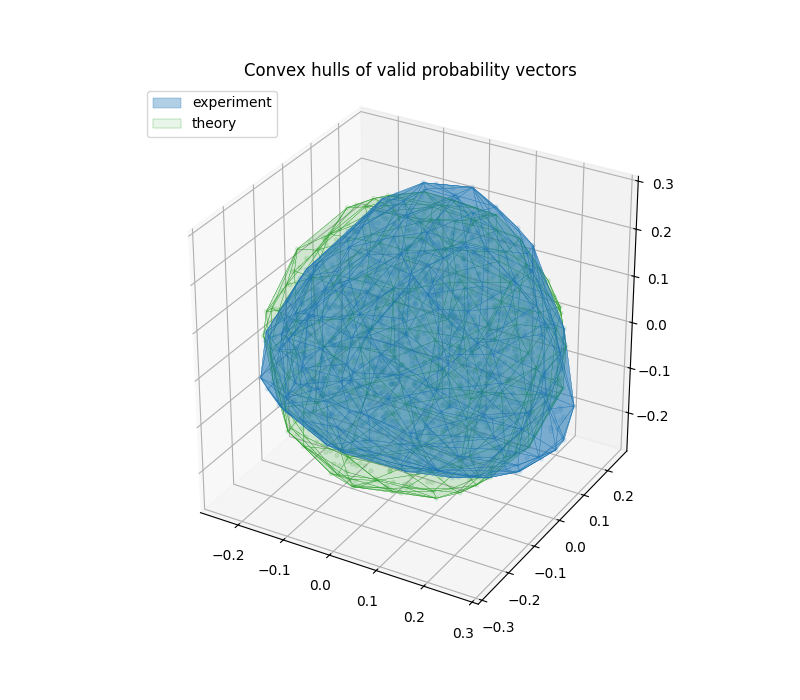

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def fit_plot_projection(prepared_hulls, plot_dim=3):
    stacked = np.vstack([prepared['reduced_points'] for prepared in prepared_hulls])
    centered = stacked - stacked.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    n_components = min(plot_dim, vh.shape[0])
    return vh[:n_components].T


def _embed_for_3d(points):
    points = np.asarray(points, dtype=float)
    if points.shape[1] >= 3:
        return points[:, :3]
    padding = np.zeros((points.shape[0], 3 - points.shape[1]))
    return np.hstack([points, padding])


def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def plot_prepared_probability_hulls(
    prepared_hulls,
    *,
    colors=None,
    labels=None,
    alphas=None,
):
    if colors is None:
        colors = [f'C{i}' for i in range(len(prepared_hulls))]
    if labels is None:
        labels = [f'set {i + 1}' for i in range(len(prepared_hulls))]
    if alphas is None:
        alphas = [0.28] * len(prepared_hulls)

    plot_basis = fit_plot_projection(prepared_hulls, plot_dim=3)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')

    legend_handles = []
    all_plot_points = []

    for prepared, color, label, alpha in zip(prepared_hulls, colors, labels, alphas):
        plot_points = _embed_for_3d(prepared['reduced_points'] @ plot_basis)
        hull_faces = [_embed_for_3d(prepared['reduced_points'][simplex] @ plot_basis) for simplex in prepared['hull'].simplices]

        all_plot_points.append(plot_points)
        ax.scatter(plot_points[:, 0], plot_points[:, 1], plot_points[:, 2], s=8, alpha=0.12, color=color)

        poly = Poly3DCollection(
            hull_faces,
            facecolor=color,
            edgecolor=color,
            linewidth=0.2,
            alpha=alpha,
        )
        ax.add_collection3d(poly)
        legend_handles.append(poly)

    stacked = np.vstack(all_plot_points)
    _set_equal_3d_axes(ax, stacked)
    ax.set_title('Convex hulls of valid probability vectors')
    ax.legend(legend_handles, labels, loc='upper left')
    plt.show()


plot_prepared_probability_hulls(
    [prepared_valid, prepared_valid_exact],
    colors=['C0', 'C2'],
    labels=['experiment', 'theory'],
    alphas=[0.35, 0.1],
)

## Higher dim

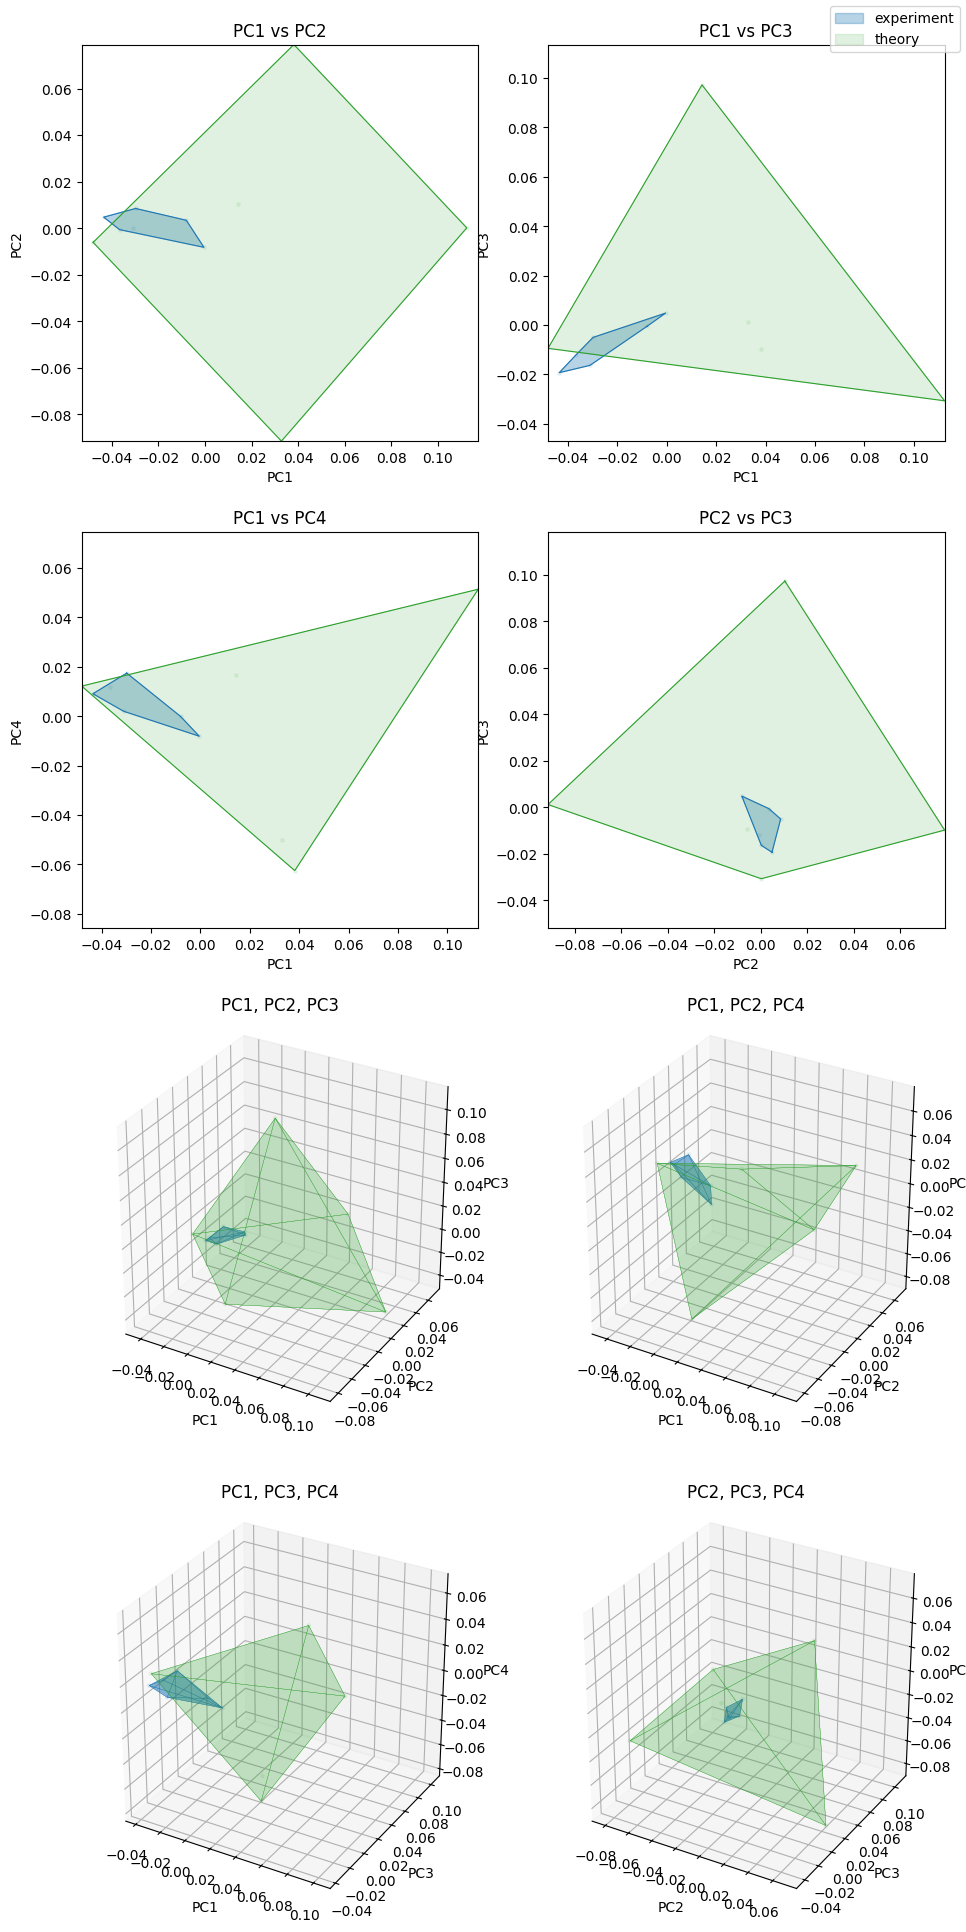

In [9]:
# Higher-dimensional hull snapshots: view the same reduced hulls through
# several 2d and 3d linear projections derived from a shared PCA basis.

from itertools import combinations
from math import ceil
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def fit_shared_pca_basis(prepared_hulls):
    stacked = np.vstack([prepared['reduced_points'] for prepared in prepared_hulls])
    centered = stacked - stacked.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    return vh.T


def default_projection_specs(prepared_hulls, max_2d=4, max_3d=4):
    basis = fit_shared_pca_basis(prepared_hulls)
    n_axes = basis.shape[1]

    pair_candidates = list(combinations(range(min(n_axes, 5)), 2))
    triple_candidates = list(combinations(range(min(n_axes, 5)), 3))

    specs = []
    for axes in pair_candidates[:max_2d]:
        specs.append({
            'dim': 2,
            'axes': axes,
            'title': 'PC{} vs PC{}'.format(axes[0] + 1, axes[1] + 1),
        })
    for axes in triple_candidates[:max_3d]:
        specs.append({
            'dim': 3,
            'axes': axes,
            'title': 'PC{}, PC{}, PC{}'.format(axes[0] + 1, axes[1] + 1, axes[2] + 1),
        })
    return specs


def project_with_shared_basis(points, shared_basis, axes):
    return points @ shared_basis[:, axes]


def _set_equal_2d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_aspect('equal')


def _set_equal_3d_axes(ax, points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    center = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    if radius == 0:
        radius = 1.0

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def _plot_2d_projected_hulls(ax, projected_sets, colors, alphas):
    all_points = []
    for points, color, alpha in zip(projected_sets, colors, alphas):
        all_points.append(points)
        ax.scatter(points[:, 0], points[:, 1], s=6, alpha=0.08, color=color)
        if len(points) >= 3:
            hull = ConvexHull(points, qhull_options='QJ')
            polygon = points[hull.vertices]
            ax.fill(polygon[:, 0], polygon[:, 1], color=color, alpha=alpha, edgecolor=color, linewidth=0.8)
            closed = np.vstack([polygon, polygon[0]])
            ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=0.8)
    _set_equal_2d_axes(ax, np.vstack(all_points))


def _plot_3d_projected_hulls(ax, projected_sets, colors, alphas):
    all_points = []
    for points, color, alpha in zip(projected_sets, colors, alphas):
        all_points.append(points)
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=6, alpha=0.08, color=color)
        if len(points) >= 4:
            hull = ConvexHull(points, qhull_options='QJ')
            faces = [points[simplex] for simplex in hull.simplices]
            poly = Poly3DCollection(
                faces,
                facecolor=color,
                edgecolor=color,
                linewidth=0.2,
                alpha=alpha,
            )
            ax.add_collection3d(poly)
    _set_equal_3d_axes(ax, np.vstack(all_points))


def plot_hulls_in_many_projections(
    prepared_hulls,
    *,
    projection_specs=None,
    colors=None,
    labels=None,
    alphas=None,
    max_2d=4,
    max_3d=4,
    figsize_scale=4.8,
):
    if colors is None:
        colors = [f'C{i}' for i in range(len(prepared_hulls))]
    if labels is None:
        labels = [f'set {i + 1}' for i in range(len(prepared_hulls))]
    if alphas is None:
        alphas = [0.28] * len(prepared_hulls)

    shared_basis = fit_shared_pca_basis(prepared_hulls)
    if projection_specs is None:
        projection_specs = default_projection_specs(prepared_hulls, max_2d=max_2d, max_3d=max_3d)

    n_panels = len(projection_specs)
    ncols = 2
    nrows = ceil(n_panels / ncols)

    fig = plt.figure(figsize=(figsize_scale * ncols, figsize_scale * nrows))
    gs = GridSpec(nrows, ncols, figure=fig)

    for index, spec in enumerate(projection_specs):
        row, col = divmod(index, ncols)
        dim = spec['dim']
        axes = tuple(spec['axes'])
        title = spec.get('title', f'{dim}d projection {axes}')

        if dim == 3:
            ax = fig.add_subplot(gs[row, col], projection='3d')
        elif dim == 2:
            ax = fig.add_subplot(gs[row, col])
        else:
            raise ValueError('Only 2d and 3d projections are supported for plotting.')

        projected_sets = [
            project_with_shared_basis(prepared['reduced_points'], shared_basis, axes)
            for prepared in prepared_hulls
        ]

        if dim == 2:
            _plot_2d_projected_hulls(ax, projected_sets, colors, alphas)
            ax.set_xlabel(f'PC{axes[0] + 1}')
            ax.set_ylabel(f'PC{axes[1] + 1}')
        else:
            _plot_3d_projected_hulls(ax, projected_sets, colors, alphas)
            ax.set_xlabel(f'PC{axes[0] + 1}')
            ax.set_ylabel(f'PC{axes[1] + 1}')
            ax.set_zlabel(f'PC{axes[2] + 1}')

        ax.set_title(title)

    handles = [Patch(facecolor=color, edgecolor=color, alpha=alpha, label=label) for color, alpha, label in zip(colors, alphas, labels)]
    fig.legend(handles=handles, loc='upper right')
    fig.tight_layout()
    plt.show()


plot_hulls_in_many_projections(
    [prepared_valid, prepared_valid_exact],
    colors=['C0', 'C2'],
    labels=['experiment', 'theory'],
    alphas=[0.32, 0.14],
    max_2d=4,
    max_3d=4,
)